# Predicting All-NBA Teams from Previous-Season Stats
**Logan Wilson · UNC Charlotte · Project 2**

**Research question:** Can I predict who will make the All-NBA 1st, 2nd or 3rd Team in a season using only that player's stats from the *previous* season?

**Target:** `tier_next`, a player's All-NBA result in season *t* (0 = none, 1 = 3rd Team, 2 = 2nd Team, 3 = 1st Team).
**Features:** everything we know about the player at the end of season *t − 1*.
**Task type:** classification. It is an imbalanced, ordered multi-class problem: only 15 of roughly 450 players are selected each year.

All numbers in the write-up come from running this notebook top to bottom.

Notebook outline:
1. Setup and data loading
2. Building the player-season table (cleaning, joins, target)
3. Exploratory data analysis
4. Feature engineering and selection
5. Train/test strategy
6. Baselines
7. Models: logistic regression, ordinal logistic regression, random forest (with tuning)
8. Evaluation on held-out seasons (2020–2025)
9. Interpretation: coefficients, permutation importance, confusion matrix, error analysis
10. Out-of-sample check on 2026 and a 2027 forecast

## 1. Setup
If any package is missing, run this once in a cell: `%pip install pandas numpy scikit-learn statsmodels matplotlib`

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, confusion_matrix, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.miscmodels.ordinal_model import OrderedModel

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
FIG = Path(".")  # charts are saved next to this notebook, ready to upload to the portfolio repo

# ---- chart style (one consistent look for every figure) -------------------
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#8a8984", "#e4e3df"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GRAY = "#c9c8c3"
# ordered tier colors: none (gray) -> 3rd -> 2nd -> 1st (light -> dark blue)
TIER_COLORS = {0: GRAY, 1: "#86b6ef", 2: "#2a78d6", 3: "#104281"}
TIER_NAMES = {0: "None", 1: "3rd Team", 2: "2nd Team", 3: "1st Team"}

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "font.family": "DejaVu Sans", "font.size": 10.5,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 24,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK2, "ytick.color": INK2, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "legend.frameon": False, "legend.labelcolor": INK2,
    "figure.dpi": 110, "savefig.dpi": 170, "savefig.bbox": "tight",
})


def subtitle(ax, text):
    """Small grey line under the chart title."""
    ax.text(0, 1.015, text, transform=ax.transAxes, fontsize=9.5, color=INK2, va="bottom")


def save(fig, name):
    fig.savefig(FIG / name)
    plt.show()

### Data sources
All tables come from **Basketball-Reference.com**, through Sumitro Datta's public GitHub mirror of its season tables. The code below downloads them straight from GitHub (pinned to the April 2026 version so results are reproducible) and keeps NBA seasons from 1997-98 onward. I use five tables:

| File | What one row is |
|---|---|
| `player_per_game.csv` | one player-season (per-game box score stats) |
| `player_advanced.csv` | one player-season (PER, TS%, WS, BPM, VORP, …) |
| `team_summaries.csv` | one team-season (wins, losses, …) |
| `end_of_season_teams.csv` | one award selection (All-NBA, All-Defense, All-Rookie) |
| `all_star_selections.csv` | one All-Star selection |

The mirror was last updated in April 2026, so it has 2025-26 stats but not the 2026 All-NBA teams (announced May 24, 2026). I entered those 15 players by hand from NBA.com (below) and use them only for a final out-of-sample check.

In [2]:
from urllib.parse import quote

# Basketball-Reference tables, mirrored on GitHub by Sumitro Datta (pinned to the April 13, 2026 commit)
BASE = ("https://raw.githubusercontent.com/sumitrodatta/bball-reference-datasets/"
        "76a70b41ad1c13948f25c62c921ed822e5db7f0e/Data/")


def load(file_name: str) -> pd.DataFrame:
    df = pd.read_csv(BASE + quote(file_name))
    return df[(df["lg"] == "NBA") & (df["season"].between(1998, 2026))].reset_index(drop=True)


per_game = load("Player Per Game.csv")
advanced = load("Advanced.csv")
teams = load("Team Summaries.csv")
awards = load("End of Season Teams.csv")
all_star = load("All-Star Selections.csv")

# 2025-26 All-NBA Teams, entered by hand from NBA.com (announced May 24, 2026)
all_nba_2026 = pd.DataFrame({
    "season": 2026,
    "number_tm": ["1st"] * 5 + ["2nd"] * 5 + ["3rd"] * 5,
    "player": ["Cade Cunningham", "Luka Dončić", "Shai Gilgeous-Alexander", "Nikola Jokić", "Victor Wembanyama",
               "Jaylen Brown", "Jalen Brunson", "Kevin Durant", "Kawhi Leonard", "Donovan Mitchell",
               "Tyrese Maxey", "Jamal Murray", "Jalen Johnson", "Chet Holmgren", "Jalen Duren"],
    "player_id": ["cunnica01", "doncilu01", "gilgesh01", "jokicni01", "wembavi01",
                  "brownja02", "brunsja01", "duranke01", "leonaka01", "mitchdo01",
                  "maxeyty01", "murraja01", "johnsja05", "holmgch01", "durenja01"],
})

for name, df in [("per_game", per_game), ("advanced", advanced), ("teams", teams),
                 ("awards", awards), ("all_star", all_star)]:
    print(f"{name:<10} {df.shape[0]:>6,} rows x {df.shape[1]:>2} cols   seasons {df.season.min()}-{df.season.max()}")

per_game   17,680 rows x 32 cols   seasons 1998-2026
advanced   17,680 rows x 30 cols   seasons 1998-2026
teams         892 rows x 31 cols   seasons 1998-2026
awards        991 rows x  7 cols   seasons 1998-2025
all_star      729 rows x  6 cols   seasons 1998-2026


## 2. Building the player-season table

### 2.1 Players traded mid-season
A player traded mid-season has one row per team **plus** a combined row (`2TM`, `3TM`, …). If I kept every row, that player-season would be counted two or three times. I keep only the combined row for traded players and the single row for everyone else. Each player's *main team* (the one he played the most games for) is saved so I can attach a team win %.

In [3]:
def one_row_per_player_season(df: pd.DataFrame) -> pd.DataFrame:
    is_combined = df["team"].str.match(r"^\dTM$")
    n_rows = df.groupby(["season", "player_id"])["team"].transform("size")
    keep = (n_rows == 1) | is_combined
    return df[keep].copy()


def main_team(df: pd.DataFrame) -> pd.DataFrame:
    """Team where the player logged the most games that season."""
    single = df[~df["team"].str.match(r"^\dTM$")]
    idx = single.groupby(["season", "player_id"])["g"].idxmax()
    return single.loc[idx, ["season", "player_id", "team"]].rename(columns={"team": "main_team"})


print("per-game rows before:", len(per_game))
pg = one_row_per_player_season(per_game).merge(main_team(per_game), on=["season", "player_id"])
adv = one_row_per_player_season(advanced)
print("per-game rows after: ", len(pg))
assert not pg.duplicated(["season", "player_id"]).any()
assert not adv.duplicated(["season", "player_id"]).any()

per-game rows before: 17680
per-game rows after:  14128


### 2.2 Joining stats, team record and awards

In [4]:
ADV_COLS = ["per", "ts_percent", "usg_percent", "ws", "ws_48", "bpm", "obpm", "dbpm", "vorp", "mp"]
df = pg.merge(adv[["season", "player_id"] + ADV_COLS], on=["season", "player_id"], how="left",
              validate="one_to_one")

# team winning percentage (league-average rows have no abbreviation -> dropped)
teams = teams.dropna(subset=["abbreviation"])
teams["team_win_pct"] = teams["w"] / (teams["w"] + teams["l"])
df = df.merge(teams[["season", "abbreviation", "team_win_pct"]],
              left_on=["season", "main_team"], right_on=["season", "abbreviation"], how="left"
              ).drop(columns="abbreviation")

# All-NBA tier each season (3 = 1st team, 2 = 2nd, 1 = 3rd)
all_nba = awards[(awards["type"] == "All-NBA") & (awards["season"] <= 2025)].copy()
all_nba["tier"] = all_nba["number_tm"].map({"1st": 3, "2nd": 2, "3rd": 1})
extra_2026 = all_nba_2026.assign(tier=all_nba_2026["number_tm"].map({"1st": 3, "2nd": 2, "3rd": 1}))
all_nba_full = pd.concat([all_nba[["season", "player_id", "tier"]], extra_2026[["season", "player_id", "tier"]]])
print(all_nba_full.groupby("season").size().tail(6))

df = df.merge(all_nba_full, on=["season", "player_id"], how="left")
df["tier"] = df["tier"].fillna(0).astype(int)

star = all_star[["season", "player_id"]].drop_duplicates().assign(all_star=1)
df = df.merge(star, on=["season", "player_id"], how="left")
df["all_star"] = df["all_star"].fillna(0).astype(int)

print(df.shape)
df[["season", "player", "main_team", "g", "pts_per_game", "vorp", "team_win_pct", "tier", "all_star"]].tail()

season
2021    15
2022    15
2023    15
2024    15
2025    15
2026    15
dtype: int64
(14128, 46)


,season,player,main_team,g,pts_per_game,vorp,team_win_pct,tier,all_star
14123,1998,Dontonio Wingfield,POR,3,0.3,0.0,0.560976,0,0
14124,1998,Joe Wolf,DEN,57,1.5,-0.7,0.134146,0,0
14125,1998,Lorenzen Wright,LAC,69,9.0,-0.3,0.207317,0,0
14126,1998,Sharone Wright,TOR,7,2.3,-0.1,0.195122,0,0
14127,1998,George Zídek,DEN,12,2.4,-0.2,0.134146,0,0


### 2.3 Status and trend features (known at the end of season *t − 1*)
A player's recent history is information we have *before* season *t* starts, so it can be used without leakage:
* `all_nba_last3`: number of All-NBA selections in seasons *t − 3* to *t − 1*
* `vorp_change`: change in VORP from *t − 2* to *t − 1* (is the player improving or declining?)

In [5]:
df = df.sort_values(["player_id", "season"])
by_player = df.groupby("player_id")

# consecutive-season check so a gap year doesn't count as "last season"
prev_season = by_player["season"].shift(1)
consecutive = prev_season == df["season"] - 1

# rolling All-NBA count over the current and two previous listed seasons
df["made_all_nba"] = (df["tier"] > 0).astype(int)
df["all_nba_last3"] = by_player["made_all_nba"].transform(lambda s: s.rolling(3, min_periods=1).sum())

df["vorp_change"] = np.where(consecutive, df["vorp"] - by_player["vorp"].shift(1), 0.0)

### 2.4 Creating the target: next season's All-NBA tier
Each row is one player's season *t − 1*. The target is the tier the same player earned in season *t*.
If a player has no row in season *t* (retired, out of the league, or missed the whole year) the target is 0, because he was not selected.

In [6]:
next_tier = all_nba_full.assign(season=all_nba_full["season"] - 1).rename(columns={"tier": "tier_next"})
df = df.merge(next_tier, on=["season", "player_id"], how="left")
df["tier_next"] = df["tier_next"].fillna(0).astype(int)

# games the player actually played the following season (used ONLY for error analysis, never as a feature)
g_next = pg[["season", "player_id", "g"]].assign(season=pg["season"] - 1).rename(columns={"g": "g_next"})
df = df.merge(g_next, on=["season", "player_id"], how="left")

df["target_season"] = df["season"] + 1
df["age_next"] = df["age"] + 1

### 2.5 Who is in the dataset?
About 450 to 700 players appear each season, and most of them have no realistic chance of making All-NBA. I keep a player-season if **either**:
* he played at least **500 minutes** (about 6 minutes a game over a full season), **or**
* he made at least one All-NBA team in the last three years. This keeps injured stars in the data, for example Stephen Curry after his 5-game 2019-20 season.

Target seasons run from **2001 to 2025** for training and testing. Features from 2025 (target 2026) are kept aside for the out-of-sample check, and 2026 features are used for a 2027 forecast.

In [7]:
keep = (df["mp"] >= 500) | (df["all_nba_last3"] > 0)
labeled = df[keep & df["target_season"].between(2001, 2025)].copy()
holdout_2026 = df[keep & (df["target_season"] == 2026)].copy()
forecast_2027 = df[keep & (df["target_season"] == 2027)].copy()

total_selections = all_nba_full[all_nba_full["season"].between(2001, 2025)].shape[0]
kept_selections = (labeled["tier_next"] > 0).sum()
print(f"Labeled player-seasons: {len(labeled):,}  ({labeled.target_season.nunique()} target seasons)")
print(f"All-NBA selections covered: {kept_selections} of {total_selections}")
print(f"Positive rate: {(labeled.tier_next > 0).mean():.2%}")

Labeled player-seasons: 8,512  (25 target seasons)
All-NBA selections covered: 375 of 375
Positive rate: 4.41%


Every one of the 375 All-NBA selections from 2001 to 2025 has a matching row for the previous season. No rookie made All-NBA in that window, so every selected player has a *t − 1* season to learn from.

### 2.6 Missing values and duplicates

In [8]:
FEATURE_CANDIDATES = ["age_next", "g", "mp_per_game", "pts_per_game", "trb_per_game", "ast_per_game",
                      "stl_per_game", "blk_per_game", "ts_percent", "usg_percent", "per", "ws", "ws_48",
                      "bpm", "vorp", "vorp_change", "team_win_pct", "tier", "all_nba_last3", "all_star"]
print("duplicate player-seasons:", labeled.duplicated(["season", "player_id"]).sum())
missing = labeled[FEATURE_CANDIDATES].isna().sum()
print(missing[missing > 0] if missing.any() else "no missing values in candidate features")

duplicate player-seasons: 0
no missing values in candidate features


There are no duplicates or missing values. Requiring 500 minutes (or recent All-NBA status) removes the tiny-sample rows where TS% or PER come back blank. The code below would impute any gaps with the season median if they showed up in future data.

In [9]:
for col in FEATURE_CANDIDATES:
    if labeled[col].isna().any():
        labeled[col] = labeled.groupby("season")[col].transform(lambda s: s.fillna(s.median()))

## 3. Exploratory data analysis
### 3.1 Summary statistics

In [10]:
summary = labeled[FEATURE_CANDIDATES].describe().T[["mean", "std", "min", "50%", "max"]].round(2)
summary

,mean,std,min,50%,max
age_next,27.70,4.26,20.00,27.00,44.00
g,64.79,14.33,2.00,67.00,85.00
mp_per_game,24.55,7.80,7.00,24.40,43.70
pts_per_game,10.45,5.83,1.20,9.10,36.10
trb_per_game,4.33,2.42,0.60,3.80,16.00
ast_per_game,2.32,1.89,0.10,1.70,11.70
stl_per_game,0.77,0.40,0.00,0.70,2.90
blk_per_game,0.50,0.49,0.00,0.30,3.70
ts_percent,0.54,0.05,0.34,0.54,0.78
usg_percent,19.15,5.11,5.10,18.60,41.70


In [11]:
labeled.groupby(labeled["tier_next"] > 0)[
    ["pts_per_game", "ts_percent", "per", "ws", "bpm", "vorp", "team_win_pct", "g", "age_next"]
].mean().round(2).rename(index={False: "Not selected next year", True: "Selected next year"})

,pts_per_game,ts_percent,per,ws,bpm,vorp,team_win_pct,g,age_next
tier_next,,,,,,,,,
Not selected next year,9.91,0.54,13.91,3.25,-0.69,0.73,0.49,64.55,27.72
Selected next year,22.21,0.57,23.08,9.76,5.06,4.51,0.59,69.88,27.22


### 3.2 The target is extremely imbalanced

           count   share
tier_next               
None        8137  0.9559
3rd Team     125  0.0147
2nd Team     125  0.0147
1st Team     125  0.0147


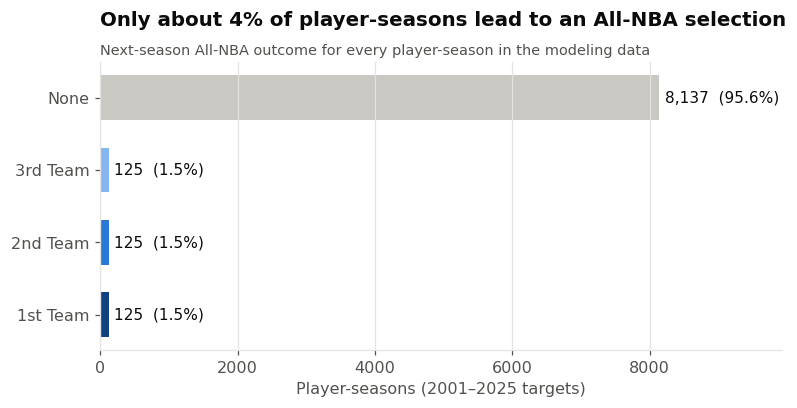

In [12]:
counts = labeled["tier_next"].value_counts().sort_index()
share = counts / counts.sum()
print(pd.DataFrame({"count": counts, "share": share.round(4)}).rename(index=TIER_NAMES))

fig, ax = plt.subplots(figsize=(8, 3.4))
order = [0, 1, 2, 3]
bars = ax.barh([TIER_NAMES[k] for k in order], [counts[k] for k in order],
               color=[TIER_COLORS[k] for k in order], height=0.62)
for b, k in zip(bars, order):
    ax.text(b.get_width() + 80, b.get_y() + b.get_height() / 2,
            f"{counts[k]:,}  ({share[k]:.1%})", va="center", color=INK, fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, counts.max() * 1.22)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Player-seasons (2001–2025 targets)")
ax.set_title("Only about 4% of player-seasons lead to an All-NBA selection")
subtitle(ax, "Next-season All-NBA outcome for every player-season in the modeling data")
save(fig, "project2-fig1-target-distribution.png")

**What this means for modeling.** A model that says "nobody makes All-NBA" is right about 96% of the time and is useless. Accuracy can't be the headline metric. I use **hits out of 15** (how many of the real 15 players end up in the model's top 15), **exact-team hits** (right player *and* right team), and **average precision** (area under the precision-recall curve), which focuses on the rare positive class.

### 3.3 How often do All-NBA players repeat?

tier_next  1st Team  2nd Team  3rd Team  None
tier                                         
3rd Team        8.8      14.4      16.0  60.8
2nd Team       13.6      23.2      16.8  46.4
1st Team       59.2      19.2       4.8  16.8
Players NOT on an All-NBA team who make one the next year: 1.9%


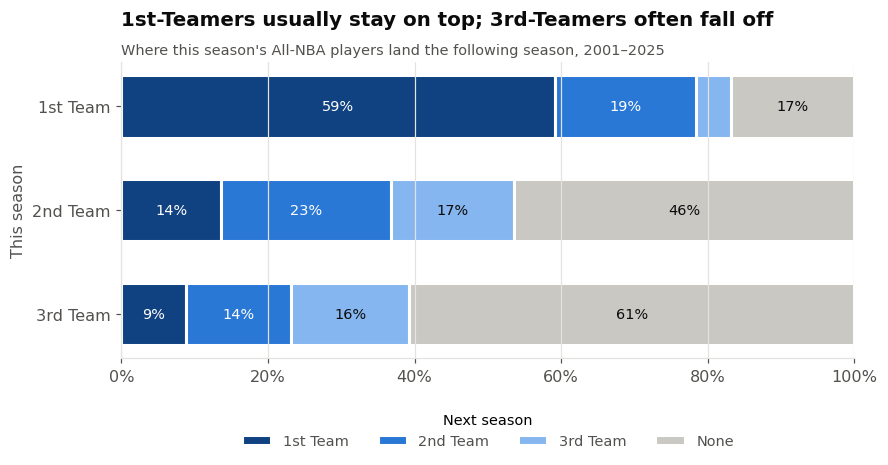

In [13]:
repeat = (labeled[labeled["tier"] > 0]
          .groupby("tier")["tier_next"].value_counts(normalize=True).unstack(fill_value=0)
          .reindex(columns=[3, 2, 1, 0], fill_value=0))
print((repeat * 100).round(1).rename(index=TIER_NAMES, columns=TIER_NAMES))
nonselected_rate = (labeled.loc[labeled["tier"] == 0, "tier_next"] > 0).mean()
print(f"Players NOT on an All-NBA team who make one the next year: {nonselected_rate:.1%}")

fig, ax = plt.subplots(figsize=(8.6, 3.5))
rows = [3, 2, 1]
left = np.zeros(len(rows))
for nxt in [3, 2, 1, 0]:
    vals = repeat.loc[rows, nxt].values
    ax.barh([TIER_NAMES[r] for r in rows], vals, left=left, color=TIER_COLORS[nxt],
            edgecolor="white", linewidth=2, height=0.6, label=TIER_NAMES[nxt])
    for i, v in enumerate(vals):
        if v >= 0.07:
            ax.text(left[i] + v / 2, i, f"{v:.0%}", ha="center", va="center", fontsize=9.5,
                    color="white" if nxt in (2, 3) else INK)
    left += vals
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.grid(axis="y", visible=False)
ax.set_ylabel("This season")
ax.set_title("1st-Teamers usually stay on top; 3rd-Teamers often fall off")
subtitle(ax, "Where this season's All-NBA players land the following season, 2001–2025")
ax.legend(title="Next season", ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.14), fontsize=9.5,
          title_fontsize=9.5)
save(fig, "project2-fig2-repeat-rates.png")

**Takeaway.** Last season's All-NBA status is the strongest single signal. Most 1st-Teamers make an All-NBA team again the next year, while 3rd-Teamers repeat far less often. Only a small share of non-selected players jump onto a team. That is why I include `tier` (this season's All-NBA result) and `all_nba_last3` as features. It also sets up a tough baseline: "run it back with last year's players."

### 3.4 Which stats separate future All-NBA players?

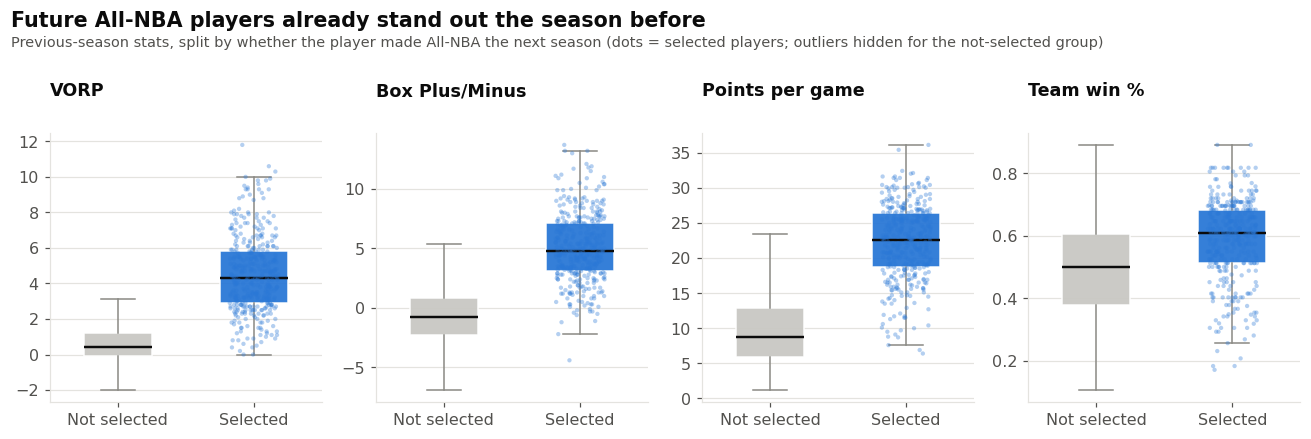

In [14]:
panels = [("vorp", "VORP"), ("bpm", "Box Plus/Minus"), ("pts_per_game", "Points per game"),
          ("team_win_pct", "Team win %")]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.8))
rng = np.random.default_rng(RANDOM_STATE)
for ax, (col, label) in zip(axes, panels):
    groups = [labeled.loc[labeled["tier_next"] == 0, col], labeled.loc[labeled["tier_next"] > 0, col]]
    bp = ax.boxplot(groups, widths=0.5, patch_artist=True, showfliers=False,
                    medianprops=dict(color=INK, linewidth=1.6), whiskerprops=dict(color=MUTED),
                    capprops=dict(color=MUTED))
    for patch, c in zip(bp["boxes"], [GRAY, BLUE]):
        patch.set_facecolor(c); patch.set_edgecolor("white"); patch.set_alpha(0.95)
    # overlay the selected players as points
    sel = groups[1]
    ax.scatter(2 + rng.uniform(-0.18, 0.18, len(sel)), sel, s=8, color=BLUE, alpha=0.35,
               edgecolor="none", zorder=3)
    ax.set_xticks([1, 2], ["Not selected", "Selected"])
    ax.grid(axis="x", visible=False)
    ax.set_title(label, fontsize=11.5)
fig.suptitle("Future All-NBA players already stand out the season before", x=0.01, ha="left",
             fontsize=13.5, fontweight="bold", color=INK, y=1.04)
fig.text(0.01, 0.955, "Previous-season stats, split by whether the player made All-NBA the next season "
         "(dots = selected players; outliers hidden for the not-selected group)",
         fontsize=9.5, color=INK2)
fig.tight_layout()
save(fig, "project2-fig3-feature-separation.png")

**Takeaway.** VORP and BPM separate the groups most clearly: the middle half of future All-NBA players sits above almost all non-selected players. Points per game separates the groups too, with more overlap. Team win % matters less but still shifts upward.

**Outliers.** The low points among the selected group are mostly stars coming off injury-shortened seasons (Curry 2020, Kawhi 2018, Paul George 2015). These are real observations, not data errors, so I keep them. They are also exactly the cases where previous-season stats should struggle.

### 3.5 Redundancy between features

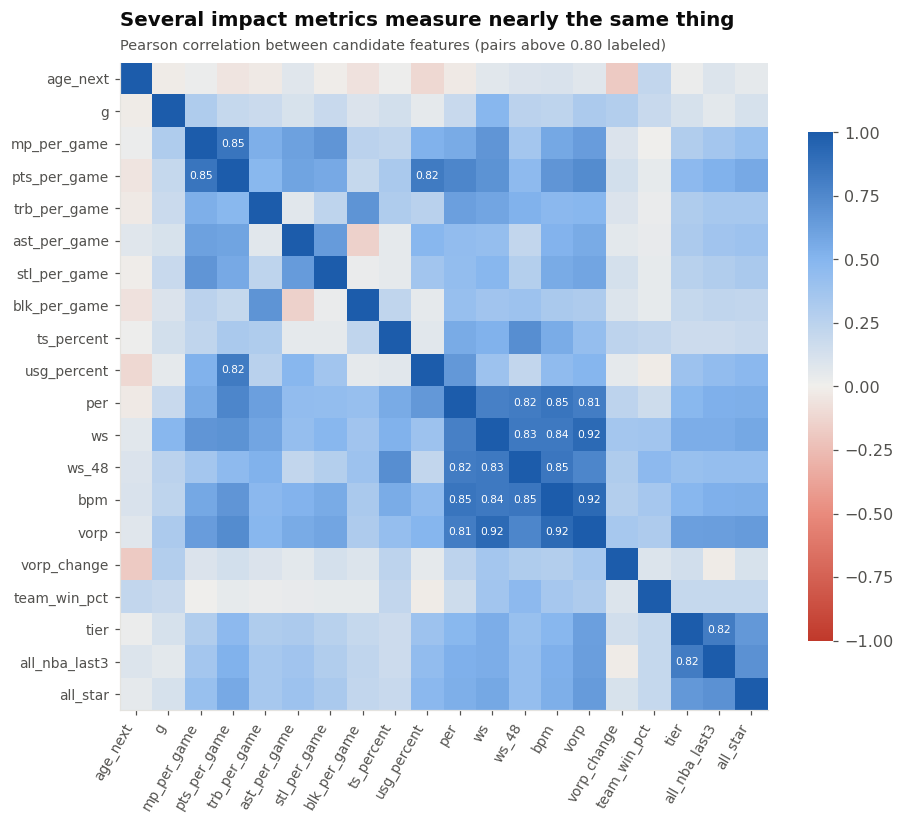

bpm           vorp             0.919587
ws            vorp             0.918206
per           bpm              0.854577
mp_per_game   pts_per_game     0.852859
ws_48         bpm              0.849337
ws            bpm              0.835149
              ws_48            0.830812
pts_per_game  usg_percent      0.824707
tier          all_nba_last3    0.817272
per           ws_48            0.815008
              vorp             0.809235
dtype: float64

In [15]:
corr = labeled[FEATURE_CANDIDATES].corr()
div = LinearSegmentedColormap.from_list("div", ["#c0392b", "#e98b7d", "#f0efec", "#86b6ef", "#1c5cab"])
fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(corr, cmap=div, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=60, ha="right", fontsize=9)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=9)
ax.grid(False)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        if abs(v) >= 0.8 and i != j:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7, color="white")
cb = fig.colorbar(im, ax=ax, shrink=0.75)
cb.outline.set_visible(False)
ax.set_title("Several impact metrics measure nearly the same thing")
subtitle(ax, "Pearson correlation between candidate features (pairs above 0.80 labeled)")
save(fig, "project2-fig4-correlation-heatmap.png")

high = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), 1)).stack()
        .loc[lambda s: s.abs() >= 0.8].sort_values(ascending=False))
high

## 4. Feature engineering and selection

**Engineered features**
* **Season z-scores for box-score stats.** League scoring has risen a lot. The average team scored about 95 points a game in the early 2000s and 110–116 in the 2020s, so 25 PPG meant more in 2004 than in 2024. I convert points, rebounds and assists into z-scores *within each season* so the model compares a player with his peers that year.
* `vorp_change`: trend from *t − 2* to *t − 1*
* `all_nba_last3`: recent sustained status

**Selection decisions (from the EDA)**
* **WS, PER and VORP** are highly correlated with each other (r ≥ 0.8). I keep **VORP** (a cumulative value measure that rewards staying on the floor) and **BPM** (a per-possession rate). I drop **WS** and **PER** to limit multicollinearity in the logistic models.
* **Minutes per game** is highly correlated with points and usage, and it mostly reflects role rather than quality, so I drop it. **Games played** stays because availability matters on its own.
* **Steals and blocks per game** and `ws_48` add little once BPM is in the model (checked by cross-validation below), so I leave them out.
* `usg_percent` and `ts_percent` stay: together they describe *how much* of the offense a player carries and *how efficiently*.

Final features (14): `age_next, g, pts_z, trb_z, ast_z, ts_percent, usg_percent, bpm, vorp, vorp_change, team_win_pct, tier, all_nba_last3, all_star`.

**Scaling and encoding.** There are no categorical text features left. `tier` is ordinal and already numeric (0–3), and `all_star` is 0/1. Numeric features are standardized for both logistic models. That step lives inside a scikit-learn `Pipeline`, so the scaler is fit only on training data. The random forest doesn't need scaling.

In [16]:
def add_season_z(frame: pd.DataFrame, reference: pd.DataFrame) -> pd.DataFrame:
    """z-score box-score stats within each season using that season's eligible players."""
    out = frame.copy()
    for col, new in [("pts_per_game", "pts_z"), ("trb_per_game", "trb_z"), ("ast_per_game", "ast_z")]:
        stats = reference.groupby("season")[col].agg(["mean", "std"])
        out[new] = (out[col] - out["season"].map(stats["mean"])) / out["season"].map(stats["std"])
    return out


eligible_all = df[keep]
labeled = add_season_z(labeled, eligible_all)
holdout_2026 = add_season_z(holdout_2026, eligible_all)
forecast_2027 = add_season_z(forecast_2027, eligible_all)

FEATURES = ["age_next", "g", "pts_z", "trb_z", "ast_z", "ts_percent", "usg_percent", "bpm", "vorp",
            "vorp_change", "team_win_pct", "tier", "all_nba_last3", "all_star"]
print(len(FEATURES), "features")

14 features


*Why z-scoring within each season isn't leakage:* the z-score for a season-*t − 1* stat only uses other players' stats from season *t − 1*, which are all known before season *t* begins. It never touches the target season.

## 5. Train/test strategy

Seasons have an order, so a random split would let the model train on 2023 and be tested on 2012. That peeks at the future, and players who appear in both halves would leak information. I split **by time**:

| Split | Target seasons | Purpose |
|---|---|---|
| Train | 2001–2019 (19 seasons) | fit models; forward-chaining CV for tuning |
| Test | 2020–2025 (6 seasons) | untouched until final comparison |
| Live check | 2026 | real out-of-sample season, labels from NBA.com |

The test window deliberately includes the COVID-shortened 2020 season and the positionless 65-game-rule era (2024–25), because those are the conditions a model would face today.

**Hyperparameter tuning** uses *forward-chaining* cross-validation inside the training years. Each fold trains on all seasons before a validation block and validates on that block: 2011–12, 2013–14, 2015–16, 2017–19.

**Leakage checks**
1. Every feature is from season *t − 1* or earlier. Next-season games (`g_next`) are kept only for error analysis.
2. Scalers are fit inside pipelines on training folds only.
3. The test seasons are used once, after all modeling choices are made.

In [17]:
train = labeled[labeled["target_season"] <= 2019].copy()
test = labeled[labeled["target_season"] >= 2020].copy()
print(f"train: {len(train):,} rows, {train.tier_next.gt(0).sum()} selections, seasons {train.target_season.min()}-{train.target_season.max()}")
print(f"test:  {len(test):,} rows, {test.tier_next.gt(0).sum()} selections, seasons {test.target_season.min()}-{test.target_season.max()}")

CV_BLOCKS = [(2011, 2012), (2013, 2014), (2015, 2016), (2017, 2019)]


def forward_folds(frame):
    for lo, hi in CV_BLOCKS:
        tr = frame["target_season"] < lo
        va = frame["target_season"].between(lo, hi)
        yield frame[tr], frame[va]

train: 6,345 rows, 285 selections, seasons 2001-2019
test:  2,167 rows, 90 selections, seasons 2020-2025


## 6. Turning scores into All-NBA teams + evaluation helpers
Every model outputs a score for each player. Each season I then **rank** players and assign the top 5 to the 1st Team, the next 5 to the 2nd Team and the next 5 to the 3rd Team, the same structure the real voting produces. This guarantees exactly 15 picks every year.

In [18]:
def assign_teams(frame: pd.DataFrame, score_col: str = "score") -> pd.DataFrame:
    out = frame.copy()
    out["rank"] = out.groupby("target_season")[score_col].rank(ascending=False, method="first")
    out["tier_pred"] = np.select([out["rank"] <= 5, out["rank"] <= 10, out["rank"] <= 15], [3, 2, 1], 0)
    return out


def season_scores(frame: pd.DataFrame) -> pd.DataFrame:
    """Per-season hits (right player, any team) and exact hits (right player, right team)."""
    g = frame.groupby("target_season")
    return pd.DataFrame({
        "hits": g.apply(lambda d: ((d.tier_pred > 0) & (d.tier_next > 0)).sum()),
        "exact": g.apply(lambda d: ((d.tier_pred > 0) & (d.tier_pred == d.tier_next)).sum()),
    })


def evaluate(frame: pd.DataFrame, name: str) -> dict:
    ranked = assign_teams(frame)
    s = season_scores(ranked)
    y = (ranked["tier_next"] > 0).astype(int)
    return {
        "model": name,
        "hits_per_15": s["hits"].mean(),
        "exact_per_15": s["exact"].mean(),
        "avg_precision": average_precision_score(y, ranked["score"]),
        "roc_auc": roc_auc_score(y, ranked["score"]),
        "accuracy_4class": (ranked["tier_pred"] == ranked["tier_next"]).mean(),
    }

## 7. Baselines
1. **Majority class:** predict "no All-NBA" for everyone. This shows why accuracy misleads.
2. **Scoring leaders:** rank players by previous-season points per game. It's the simplest thing a casual fan might do.
3. **Run it back:** last year's All-NBA players, ordered by their team (1st, then 2nd, then 3rd). Open spots go to the top scorers. This is a strong, knowledge-based baseline.

In [19]:
def baseline_scores(frame):
    out = {}
    out["Majority class"] = frame.assign(score=0.0 + rng.uniform(0, 1e-9, len(frame)))
    out["Baseline: scoring leaders"] = frame.assign(score=frame["pts_per_game"])
    out["Baseline: run it back"] = frame.assign(score=frame["tier"] * 100 + frame["pts_per_game"])
    return out


baseline_rows = []
for name, scored in baseline_scores(test).items():
    r = evaluate(scored, name)
    if name == "Majority class":  # the majority baseline picks nobody
        y = (scored["tier_next"] > 0)
        r.update(hits_per_15=0, exact_per_15=0, accuracy_4class=(scored["tier_next"] == 0).mean())
    baseline_rows.append(r)
pd.DataFrame(baseline_rows).round(3)

,model,hits_per_15,exact_per_15,avg_precision,roc_auc,accuracy_4class
0,Majority class,0.000,0.000,0.056,0.517,0.958
1,Baseline: scoring leaders,7.833,3.167,0.461,0.954,0.947
2,Baseline: run it back,8.000,5.667,0.542,0.965,0.955


The majority class scores about **96% accuracy while finding zero All-NBA players**, which shows why accuracy is the wrong metric here. "Run it back" is the baseline to beat.

## 8. Models

| Model | Why it fits this problem |
|---|---|
| **Logistic regression** (binary: any All-NBA team vs none) | Interpretable coefficients and a probability for every player. Players are then ranked into teams. |
| **Ordinal logistic regression** (None < 3rd < 2nd < 1st) | Uses the *order* of the teams directly, as planned in my proposal. The score is the expected tier. |
| **Random forest** (binary) | Captures non-linear effects and interactions (for example, scoring matters more on a winning team) without scaling. |

### 8.1 Tuning with forward-chaining CV
I tune on **average precision**, the metric that focuses on how well the model ranks the rare positive class.

In [20]:
def cv_score(make_model, frame=train, features=FEATURES):
    aps, hits = [], []
    for tr, va in forward_folds(frame):
        m = make_model()
        m.fit(tr[features], (tr["tier_next"] > 0).astype(int))
        scored = va.assign(score=m.predict_proba(va[features])[:, 1])
        aps.append(average_precision_score((va["tier_next"] > 0).astype(int), scored["score"]))
        hits.append(season_scores(assign_teams(scored))["hits"].mean())
    return np.mean(aps), np.mean(hits)


# Logistic regression: regularization strength and class weighting
lr_grid = []
for C in [0.01, 0.1, 1, 10]:
    for cw in [None, "balanced"]:
        ap, h = cv_score(lambda: make_pipeline(StandardScaler(),
                                               LogisticRegression(C=C, class_weight=cw, max_iter=5000)))
        lr_grid.append({"C": C, "class_weight": str(cw), "cv_avg_precision": ap, "cv_hits_per_15": h})
lr_grid = pd.DataFrame(lr_grid).sort_values("cv_avg_precision", ascending=False)
lr_grid.round(3)

,C,class_weight,cv_avg_precision,cv_hits_per_15
1,0.01,balanced,0.657,9.375
2,0.10,None,0.655,9.167
5,1.00,balanced,0.654,8.917
7,10.00,balanced,0.653,8.917
3,0.10,balanced,0.653,9.042
4,1.00,None,0.652,9.167
6,10.00,None,0.652,9.167
0,0.01,None,0.640,9.125


In [21]:
rf_grid = []
for depth in [4, 8, None]:
    for leaf in [1, 5, 20]:
        for mf in ["sqrt", 0.5]:
            ap, h = cv_score(lambda: RandomForestClassifier(
                n_estimators=300, max_depth=depth, min_samples_leaf=leaf, max_features=mf,
                n_jobs=-1, random_state=RANDOM_STATE))
            rf_grid.append({"max_depth": str(depth), "min_samples_leaf": leaf, "max_features": str(mf),
                            "cv_avg_precision": ap, "cv_hits_per_15": h})
rf_grid = pd.DataFrame(rf_grid).sort_values("cv_avg_precision", ascending=False)
rf_grid.head(8).round(3)

,max_depth,min_samples_leaf,max_features,cv_avg_precision,cv_hits_per_15
14,None,5,sqrt,0.624,8.833
8,8,5,sqrt,0.624,8.708
6,8,1,sqrt,0.621,8.708
2,4,5,sqrt,0.621,8.958
4,4,20,sqrt,0.621,8.583
10,8,20,sqrt,0.620,8.792
1,4,1,0.5,0.620,8.375
16,None,20,sqrt,0.619,8.500


In [22]:
best_lr = lr_grid.iloc[0]
best_rf = rf_grid.iloc[0]
LR_C = float(best_lr["C"])
LR_CW = None if best_lr["class_weight"] == "None" else "balanced"
RF_PARAMS = dict(max_depth=None if best_rf["max_depth"] == "None" else int(best_rf["max_depth"]),
                 min_samples_leaf=int(best_rf["min_samples_leaf"]),
                 max_features=best_rf["max_features"] if best_rf["max_features"] == "sqrt" else float(best_rf["max_features"]))
print("Best LR:", LR_C, LR_CW)
print("Best RF:", RF_PARAMS)


def make_lr():
    return make_pipeline(StandardScaler(), LogisticRegression(C=LR_C, class_weight=LR_CW, max_iter=5000))


def make_rf():
    return RandomForestClassifier(n_estimators=600, n_jobs=-1, random_state=RANDOM_STATE, **RF_PARAMS)

Best LR: 0.01 balanced
Best RF: {'max_depth': None, 'min_samples_leaf': 5, 'max_features': 'sqrt'}


**Checking the feature-selection choices with the same CV.** I compare the chosen 14 features against using every candidate feature (raw per-game stats, WS, PER, minutes, steals, blocks, …).

In [23]:
ALL_FEATURES = FEATURE_CANDIDATES + ["pts_z", "trb_z", "ast_z"]
for label, feats in [("14 selected features", FEATURES), ("all 23 candidates", ALL_FEATURES)]:
    ap_lr, h_lr = cv_score(make_lr, features=feats)
    ap_rf, h_rf = cv_score(make_rf, features=feats)
    print(f"{label:<22} LR AP={ap_lr:.3f} hits={h_lr:.2f} | RF AP={ap_rf:.3f} hits={h_rf:.2f}")

14 selected features   LR AP=0.657 hits=9.38 | RF AP=0.625 hits=8.71
all 23 candidates      LR AP=0.650 hits=9.17 | RF AP=0.622 hits=9.00


The smaller feature set performs about the same as the full set in cross-validation, with no meaningful loss. It is easier to interpret and has less multicollinearity, so I keep it.

### 8.2 Ordinal logistic regression
statsmodels' `OrderedModel` fits one set of coefficients plus three cut-points (None|3rd, 3rd|2nd, 2nd|1st). I standardize features using training-set means and SDs, then score each player by **expected tier** = Σ k · P(tier = k).

In [24]:
class OrdinalLogit:
    """Small wrapper so the ordinal model has the same fit/score interface."""

    def fit(self, X, y):
        self.scaler = StandardScaler().fit(X)
        Xs = pd.DataFrame(self.scaler.transform(X), columns=X.columns, index=X.index)
        self.res = OrderedModel(y.values, Xs, distr="logit").fit(method="bfgs", maxiter=2000, disp=False)
        return self

    def predict_tier_proba(self, X):
        Xs = pd.DataFrame(self.scaler.transform(X), columns=X.columns, index=X.index)
        return np.asarray(self.res.predict(Xs))

    def expected_tier(self, X):
        return self.predict_tier_proba(X) @ np.arange(4)


ord_cv = []
for tr, va in forward_folds(train):
    m = OrdinalLogit().fit(tr[FEATURES], tr["tier_next"])
    scored = va.assign(score=m.expected_tier(va[FEATURES]))
    ord_cv.append((average_precision_score((va.tier_next > 0).astype(int), scored.score),
                   season_scores(assign_teams(scored))["hits"].mean()))
print("Ordinal CV  AP=%.3f  hits=%.2f" % tuple(np.mean(ord_cv, axis=0)))

Ordinal CV  AP=0.651  hits=9.17


## 9. Final comparison on the held-out test seasons (2020–2025)
All three models are refit on **all training seasons (2001–2019)** with the tuned settings and scored once on the test seasons.

In [25]:
y_train_bin = (train["tier_next"] > 0).astype(int)

lr = make_lr().fit(train[FEATURES], y_train_bin)
rf = make_rf().fit(train[FEATURES], y_train_bin)
ordl = OrdinalLogit().fit(train[FEATURES], train["tier_next"])

scored_test = {
    "Logistic regression": test.assign(score=lr.predict_proba(test[FEATURES])[:, 1]),
    "Ordinal logistic": test.assign(score=ordl.expected_tier(test[FEATURES])),
    "Random forest": test.assign(score=rf.predict_proba(test[FEATURES])[:, 1]),
}

results = pd.DataFrame(baseline_rows + [evaluate(s, n) for n, s in scored_test.items()])
results = results.set_index("model")
results.round(3)

,hits_per_15,exact_per_15,avg_precision,roc_auc,accuracy_4class
model,,,,,
Majority class,0.000,0.000,0.056,0.517,0.958
Baseline: scoring leaders,7.833,3.167,0.461,0.954,0.947
Baseline: run it back,8.000,5.667,0.542,0.965,0.955
Logistic regression,8.667,4.333,0.609,0.972,0.953
Ordinal logistic,8.500,4.667,0.594,0.970,0.953
Random forest,8.667,6.000,0.586,0.971,0.958


### 9.1 What each metric measures
* **Hits per 15:** of the 15 players the model puts on All-NBA teams, how many actually made one, averaged over the six test seasons. This is precision *and* recall at the same time, because both lists have exactly 15 players.
* **Exact per 15:** right player *and* right team (1st, 2nd or 3rd).
* **Average precision (AP):** summarizes the precision-recall curve over the whole ranking. It rewards putting real selections near the top and is the standard metric for rare-event ranking. A random ranking would score about the positive rate (≈ 0.04).
* **ROC AUC:** probability that a random future All-NBA player is ranked above a random non-selected player. It looks flattering on imbalanced data, so I report it only for context.
* **4-class accuracy:** shown to make the point that it is dominated by the "None" class.

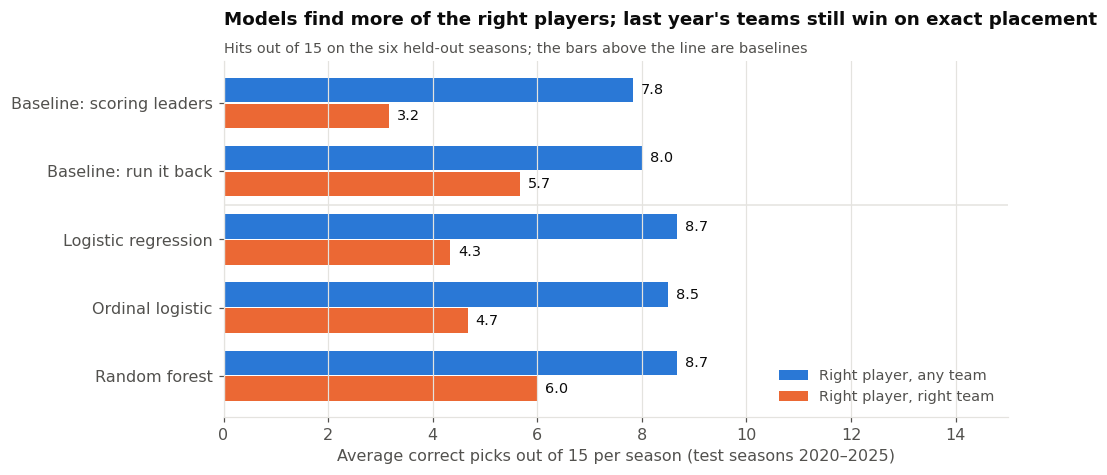

In [26]:
plot_models = ["Baseline: scoring leaders", "Baseline: run it back", "Logistic regression",
               "Ordinal logistic", "Random forest"]
pr = results.loc[plot_models]
fig, ax = plt.subplots(figsize=(9.2, 4.2))
y = np.arange(len(plot_models))
h = 0.36
b1 = ax.barh(y - h / 2 - 0.01, pr["hits_per_15"], height=h, color=BLUE, label="Right player, any team")
b2 = ax.barh(y + h / 2 + 0.01, pr["exact_per_15"], height=h, color=ORANGE, label="Right player, right team")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_width() + 0.15, b.get_y() + b.get_height() / 2, f"{b.get_width():.1f}",
                va="center", fontsize=9.5, color=INK)
ax.set_yticks(y, plot_models)
ax.invert_yaxis()
ax.set_xlim(0, 15)
ax.set_xlabel("Average correct picks out of 15 per season (test seasons 2020–2025)")
ax.grid(axis="y", visible=False)
ax.axhline(1.5, color=GRID, lw=1)
ax.legend(loc="lower right", fontsize=9.5)
ax.set_title("Models find more of the right players; last year's teams still win on exact placement", fontsize=12)
subtitle(ax, "Hits out of 15 on the six held-out seasons; the bars above the line are baselines")
save(fig, "project2-fig5-model-comparison.png")

In [27]:
per_season = pd.concat({n: season_scores(assign_teams(s)) for n, s in
                        {**{k: v for k, v in baseline_scores(test).items() if k != "Majority class"},
                         **scored_test}.items()}, axis=1)
per_season

Baseline: scoring leaders       Baseline: run it back       Logistic regression       Ordinal logistic       Random forest      
                                   hits exact                  hits exact                hits exact             hits exact          hits exact
target_season                                                                                                                                 
2020                                  6     4                     8     6                   9     5                9     3             9     7
2021                                  7     1                     9     6                   9     7                9     8             9     5
2022                                  9     3                     7     4                   8     3                8     3             8     5
2023                                  8     4                     7     5                   7     4                7     5             7     5
2024                                  8     5                     8     6                  10     4                9     5            10     6
2025                                  9     2                     9     7                   9     3                9     4             9     8

Highest test AP: Logistic regression


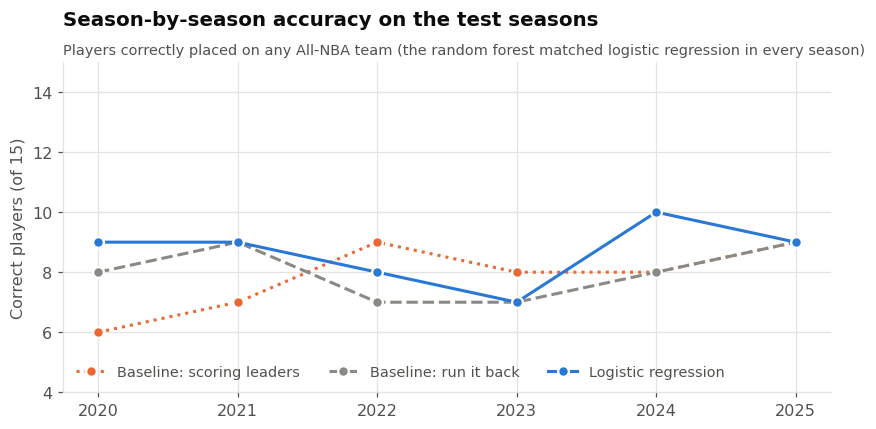

In [28]:
FINAL = "Logistic regression"  # chosen below; kept as a variable so every later cell follows the choice
best_model_name = results.loc[["Logistic regression", "Ordinal logistic", "Random forest"],
                              "avg_precision"].idxmax()
print("Highest test AP:", best_model_name)

fig, ax = plt.subplots(figsize=(9, 3.9))
seasons = per_season.index
series = [("Baseline: scoring leaders", ORANGE, ":"), ("Baseline: run it back", MUTED, "--"),
          ("Logistic regression", BLUE, "-")]
for name, color, ls in series:
    vals = per_season[(name, "hits")]
    ax.plot(seasons, vals, color=color, lw=2, ls=ls, marker="o", ms=7, mec="white", mew=1.5, label=name)
ax.set_ylim(4, 15)
ax.set_xticks(seasons)
ax.set_ylabel("Correct players (of 15)")
ax.legend(loc="lower left", fontsize=9.5, ncol=3)
ax.set_title("Season-by-season accuracy on the test seasons")
subtitle(ax, "Players correctly placed on any All-NBA team (the random forest matched logistic regression in every season)")
save(fig, "project2-fig6-hits-by-season.png")

### 9.2 Choosing the final model
See the write-up for the discussion. In short, the three models are close, and the regularized **logistic regression** is selected because it:
* has the best average precision on the test seasons and is tied for the most hits per 15,
* also had the best cross-validated average precision and hits inside the training years, so the test result isn't a one-off,
* has coefficients that can be explained to a nontechnical reader.

**Tradeoff:** the random forest places more players on the *exact* right team, and the "run it back" baseline is best of all at exact placement. Last year's 1st-Teamers usually stay 1st-Teamers, so ordering by last year's team is hard to beat once you already have the right names.

The random forest does not beat it despite being more flexible. With ~375 positive examples and a signal that is mostly "better players stay better," a linear score is enough, and the forest's extra flexibility mostly fits noise. The ordinal model gives very similar rankings. Its extra tier structure doesn't help, because the ranking step already turns a score into teams.

In [29]:
print(results.loc[["Logistic regression", "Ordinal logistic", "Random forest"]].round(3))
cv_compare = pd.DataFrame({
    "Logistic regression": lr_grid.iloc[0][["cv_avg_precision", "cv_hits_per_15"]].values,
    "Random forest": rf_grid.iloc[0][["cv_avg_precision", "cv_hits_per_15"]].values,
    "Ordinal logistic": np.mean(ord_cv, axis=0),
}, index=["cv_avg_precision", "cv_hits_per_15"]).T.astype(float)
cv_compare.round(3)

                     hits_per_15  exact_per_15  avg_precision  roc_auc  accuracy_4class
model                                                                                  
Logistic regression        8.667         4.333          0.609    0.972            0.953
Ordinal logistic           8.500         4.667          0.594    0.970            0.953
Random forest              8.667         6.000          0.586    0.971            0.958


,cv_avg_precision,cv_hits_per_15
Logistic regression,0.657,9.375
Random forest,0.624,8.833
Ordinal logistic,0.651,9.167


## 10. Interpretation
### 10.1 Logistic regression coefficients

age_next         0.58
vorp_change      0.87
g                0.87
tier             0.98
all_star         1.08
ts_percent       1.19
team_win_pct     1.31
all_nba_last3    1.34
bpm              1.34
usg_percent      1.41
ast_z            1.53
pts_z            1.58
vorp             1.73
trb_z            2.16
Name: odds multiplier per +1 SD, dtype: float64


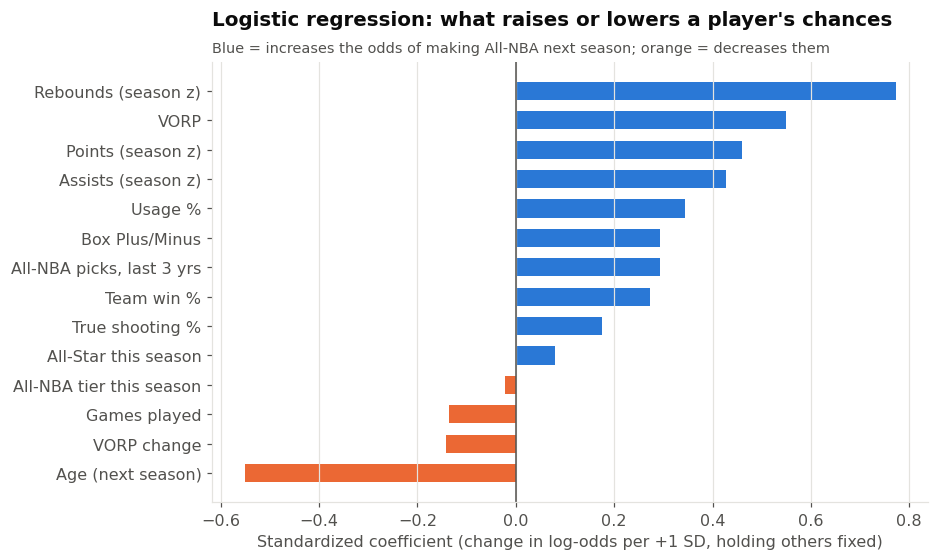

In [30]:
coefs = pd.Series(lr.named_steps["logisticregression"].coef_[0], index=FEATURES).sort_values()
nice = {"age_next": "Age (next season)", "g": "Games played", "pts_z": "Points (season z)",
        "trb_z": "Rebounds (season z)", "ast_z": "Assists (season z)", "ts_percent": "True shooting %",
        "usg_percent": "Usage %", "bpm": "Box Plus/Minus", "vorp": "VORP", "vorp_change": "VORP change",
        "team_win_pct": "Team win %", "tier": "All-NBA tier this season",
        "all_nba_last3": "All-NBA picks, last 3 yrs", "all_star": "All-Star this season"}
print((np.exp(coefs)).round(2).rename("odds multiplier per +1 SD"))

fig, ax = plt.subplots(figsize=(8.4, 5.2))
colors = [BLUE if v > 0 else ORANGE for v in coefs.values]
ax.barh([nice[c] for c in coefs.index], coefs.values, color=colors, height=0.62)
ax.axvline(0, color=INK2, lw=1)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Standardized coefficient (change in log-odds per +1 SD, holding others fixed)")
ax.set_title("Logistic regression: what raises or lowers a player's chances")
subtitle(ax, "Blue = increases the odds of making All-NBA next season; orange = decreases them")
save(fig, "project2-fig7-lr-coefficients.png")

**Reading the coefficients carefully.** Each coefficient is a feature's effect *holding the others fixed*. Correlated features split the credit. `tier` (this season's All-NBA result) looks near zero, but not because status doesn't matter. The same information is already carried by `all_nba_last3` (r = 0.82) and VORP. To see what each *kind* of information is worth, I use **grouped permutation importance**: shuffle a whole group of related columns together on the test seasons and measure how much average precision drops. Shuffling the whole group means correlated features can't cover for each other.

                                               Logistic regression  Random forest
Availability (games played)                                  0.002         -0.001
Efficiency (TS%)                                             0.002         -0.000
Team win %                                                   0.006         -0.011
Trend (VORP change)                                          0.006         -0.000
Age                                                          0.009         -0.010
Status (All-NBA tier, last-3 count, All-Star)                0.030          0.060
Overall impact (VORP, BPM)                                   0.103          0.071
Box-score production (pts, reb, ast, usage)                  0.341          0.082


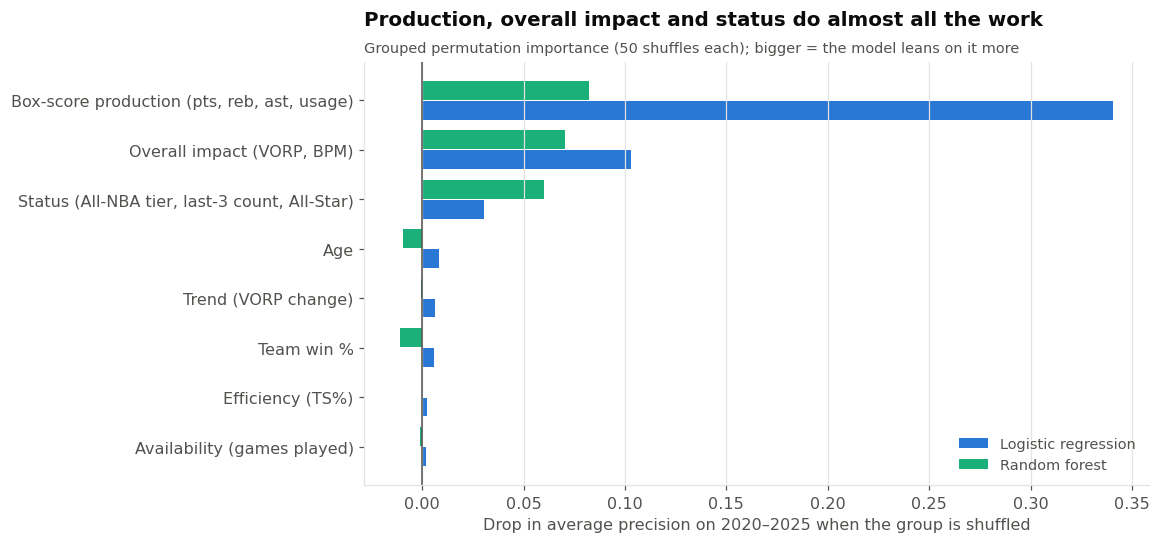

In [31]:
GROUPS = {
    "Overall impact (VORP, BPM)": ["vorp", "bpm"],
    "Box-score production (pts, reb, ast, usage)": ["pts_z", "trb_z", "ast_z", "usg_percent"],
    "Status (All-NBA tier, last-3 count, All-Star)": ["tier", "all_nba_last3", "all_star"],
    "Age": ["age_next"],
    "Team win %": ["team_win_pct"],
    "Availability (games played)": ["g"],
    "Efficiency (TS%)": ["ts_percent"],
    "Trend (VORP change)": ["vorp_change"],
}


def grouped_permutation(model, frame, n_repeats=50, seed=RANDOM_STATE):
    y = (frame["tier_next"] > 0).astype(int)
    base = average_precision_score(y, model.predict_proba(frame[FEATURES])[:, 1])
    r = np.random.default_rng(seed)
    out = {}
    for g, cols in GROUPS.items():
        drops = []
        for _ in range(n_repeats):
            X = frame[FEATURES].copy()
            idx = r.permutation(len(X))
            X[cols] = X[cols].values[idx]
            drops.append(base - average_precision_score(y, model.predict_proba(X)[:, 1]))
        out[g] = (np.mean(drops), np.std(drops))
    return pd.DataFrame(out, index=["mean_drop", "sd"]).T


imp_lr = grouped_permutation(lr, test)
imp_rf = grouped_permutation(rf, test)
imp = pd.DataFrame({"Logistic regression": imp_lr["mean_drop"], "Random forest": imp_rf["mean_drop"]})
imp = imp.sort_values("Logistic regression")
print(imp.round(3))

fig, ax = plt.subplots(figsize=(9.2, 5))
yy = np.arange(len(imp))
hh = 0.38
ax.barh(yy - hh / 2 - 0.01, imp["Logistic regression"], height=hh, color=BLUE, label="Logistic regression")
ax.barh(yy + hh / 2 + 0.01, imp["Random forest"], height=hh, color=AQUA, label="Random forest")
ax.set_yticks(yy, imp.index)
ax.axvline(0, color=INK2, lw=1)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Drop in average precision on 2020–2025 when the group is shuffled")
ax.legend(loc="lower right", fontsize=9.5)
ax.set_title("Production, overall impact and status do almost all the work")
subtitle(ax, "Grouped permutation importance (50 shuffles each); bigger = the model leans on it more")
save(fig, "project2-fig7b-grouped-importance.png")

### 10.2 Confusion matrix (final model, test seasons pooled)

                 Pred 1st Team  Pred 2nd Team  Pred 3rd Team  Pred None
Actual 1st Team             19              5              2          4
Actual 2nd Team              3              4              9         14
Actual 3rd Team              1              6              3         20
Actual None                  7             15             16       2039


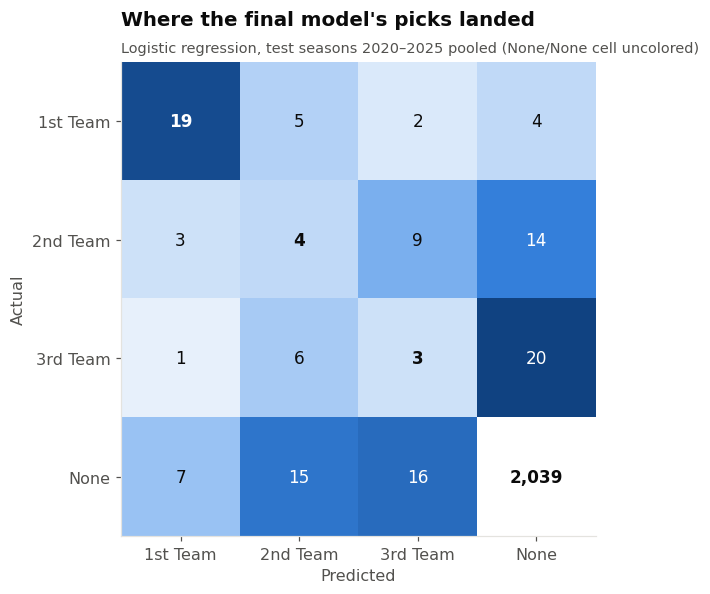

In [32]:
final_ranked = assign_teams(scored_test[FINAL])
labels = [3, 2, 1, 0]
cm = confusion_matrix(final_ranked["tier_next"], final_ranked["tier_pred"], labels=labels)
cm_df = pd.DataFrame(cm, index=[f"Actual {TIER_NAMES[k]}" for k in labels],
                     columns=[f"Pred {TIER_NAMES[k]}" for k in labels])
print(cm_df)

seq = LinearSegmentedColormap.from_list("seq", ["#f4f8fd", "#9ec5f4", "#3987e5", "#104281"])
fig, ax = plt.subplots(figsize=(6.6, 5.6))
show = cm.astype(float).copy()
show[3, 3] = np.nan  # the huge None/None cell would wash out the color scale
im = ax.imshow(np.ma.masked_invalid(show), cmap=seq, vmin=0, vmax=np.nanmax(show))
for i in range(4):
    for j in range(4):
        v = cm[i, j]
        dark = (not np.isnan(show[i, j])) and show[i, j] > np.nanmax(show) * 0.5
        ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=11,
                color="white" if dark else INK, fontweight="bold" if i == j else "normal")
ax.set_xticks(range(4), [TIER_NAMES[k] for k in labels])
ax.set_yticks(range(4), [TIER_NAMES[k] for k in labels])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.grid(False)
ax.set_title("Where the final model's picks landed")
subtitle(ax, "Logistic regression, test seasons 2020–2025 pooled (None/None cell uncolored)")
save(fig, "project2-fig8-confusion-matrix.png")

### 10.3 Error analysis: who does the model miss?

In [33]:
fr = final_ranked.copy()
fp = fr[(fr.tier_pred > 0) & (fr.tier_next == 0)]
fn = fr[(fr.tier_pred == 0) & (fr.tier_next > 0)]
print(f"False positives (picked, not selected): {len(fp)}")
print(f"  ...of those, played < 65 games the next season or didn't play: {(fp.g_next.fillna(0) < 65).sum()}")
print(f"False negatives (selected, not picked): {len(fn)}")
print(f"  ...of those, no All-NBA team in the previous 3 seasons (first-timers): {(fn.all_nba_last3 == 0).sum()}")

cols = ["target_season", "player", "age_next", "pts_per_game", "vorp", "tier", "score", "rank", "tier_next", "g_next"]
print("\nFalse positives")
display(fp[cols].sort_values(["target_season", "rank"]).round(3))
print("\nFalse negatives")
display(fn[cols].sort_values(["target_season", "rank"]).round(3))

False positives (picked, not selected): 38
  ...of those, played < 65 games the next season or didn't play: 25
False negatives (selected, not picked): 38
  ...of those, no All-NBA team in the previous 3 seasons (first-timers): 24

False positives


,target_season,player,age_next,pts_per_game,vorp,tier,score,rank,tier_next,g_next
3844,2020,Joel Embiid,25.0,27.5,3.8,2,0.998,5.0,0,51.0
12636,2020,Karl-Anthony Towns,24.0,24.4,5.1,0,0.995,8.0,0,35.0
3693,2020,Kevin Durant,31.0,26.0,5.1,2,0.991,9.0,0,NaN
4557,2020,Paul George,29.0,28.0,6.6,3,0.990,10.0,0,48.0
2986,2020,Stephen Curry,31.0,27.3,5.1,3,0.988,11.0,0,5.0
6213,2020,Kyrie Irving,27.0,23.8,5.1,2,0.974,14.0,0,20.0
5202,2021,James Harden,31.0,34.3,7.3,3,0.999,2.0,0,44.0
3089,2021,Anthony Davis,27.0,26.1,5.4,3,0.995,6.0,0,36.0
12637,2021,Karl-Anthony Towns,25.0,26.5,2.9,0,0.990,10.0,0,50.0
13391,2021,Russell Westbrook,32.0,27.2,1.8,1,0.984,11.0,0,65.0



False negatives


,target_season,player,age_next,pts_per_game,vorp,tier,score,rank,tier_next,g_next
11601,2020,Ben Simmons,23.0,16.9,3.8,0,0.960,17.0,1,57.0
3459,2020,Luka Dončić,20.0,21.2,3.4,0,0.943,19.0,3,61.0
2039,2020,Jimmy Butler,30.0,18.7,3.2,0,0.778,28.0,1,58.0
11582,2020,Pascal Siakam,25.0,16.9,2.8,0,0.597,41.0,2,60.0
10064,2020,Chris Paul,34.0,15.6,2.8,0,0.532,44.0,2,70.0
12252,2020,Jayson Tatum,21.0,15.7,1.1,0,0.343,64.0,1,66.0
2040,2021,Jimmy Butler,31.0,19.9,3.7,1,0.936,17.0,1,52.0
4558,2021,Paul George,30.0,21.5,2.5,0,0.932,19.0,1,54.0
2987,2021,Stephen Curry,32.0,20.8,0.2,0,0.847,24.0,3,63.0
1011,2021,Bradley Beal,27.0,30.5,2.5,0,0.827,26.0,1,60.0


In [34]:
# how often does availability explain a false positive vs. the base rate for true positives?
tp = fr[(fr.tier_pred > 0) & (fr.tier_next > 0)]
print("Median games next season - true positives:", tp.g_next.median(), " false positives:", fp.g_next.fillna(0).median())

Median games next season - true positives: 68.0  false positives: 51.0


### 10.4 Example predictions: the 2025 season (model trained on 2001–2019 only)

In [35]:
ex = fr[fr.target_season == 2025].sort_values("rank").head(20)
ex[["rank", "player", "score", "tier_pred", "tier_next", "g_next"]].assign(
    predicted=lambda d: d.tier_pred.map(TIER_NAMES), actual=lambda d: d.tier_next.map(TIER_NAMES)
)[["rank", "player", "score", "predicted", "actual", "g_next"]].round(3)

,rank,player,score,predicted,actual,g_next
6820,1.0,Nikola Jokić,1.000,1st Team,1st Team,70.0
3464,2.0,Luka Dončić,1.000,1st Team,None,50.0
3849,3.0,Joel Embiid,1.000,1st Team,None,19.0
383,4.0,Giannis Antetokounmpo,1.000,1st Team,1st Team,67.0
11277,5.0,Domantas Sabonis,0.998,1st Team,None,70.0
4609,6.0,Shai Gilgeous-Alexander,0.997,2nd Team,1st Team,76.0
12257,7.0,Jayson Tatum,0.996,2nd Team,1st Team,72.0
3093,8.0,Anthony Davis,0.983,2nd Team,None,51.0
6452,9.0,LeBron James,0.982,2nd Team,2nd Team,70.0
5088,10.0,Tyrese Haliburton,0.974,2nd Team,3rd Team,73.0


## 11. Out-of-sample check on 2026 and a 2027 forecast
The final model is refit on **every labeled season (2001–2025)** and then:
1. predicts the **2026** teams from 2024-25 stats. These labels were never used anywhere above.
2. forecasts **2027** from 2025-26 stats.

In [36]:
y_all = (labeled["tier_next"] > 0).astype(int)
final_model = make_lr().fit(labeled[FEATURES], y_all)

pred26 = assign_teams(holdout_2026.assign(score=final_model.predict_proba(holdout_2026[FEATURES])[:, 1]))
s26 = season_scores(pred26)
print("2026 hits:", int(s26.hits.iloc[0]), "of 15  | exact team:", int(s26.exact.iloc[0]))
top26 = pred26.sort_values("rank").head(15)
top26[["rank", "player", "score", "tier_pred", "tier_next", "g_next"]].assign(
    predicted=lambda d: d.tier_pred.map(TIER_NAMES), actual=lambda d: d.tier_next.map(TIER_NAMES)
)[["rank", "player", "score", "predicted", "actual", "g_next"]].round(3)

2026 hits: 6 of 15  | exact team: 3


,rank,player,score,predicted,actual,g_next
6821,1.0,Nikola Jokić,1.000,1st Team,1st Team,65.0
384,2.0,Giannis Antetokounmpo,1.000,1st Team,None,36.0
4610,3.0,Shai Gilgeous-Alexander,1.000,1st Team,1st Team,68.0
3465,4.0,Luka Dončić,0.999,1st Team,1st Team,64.0
12258,5.0,Jayson Tatum,0.997,1st Team,None,16.0
11278,6.0,Domantas Sabonis,0.995,2nd Team,None,19.0
6453,7.0,LeBron James,0.982,2nd Team,None,60.0
13361,8.0,Victor Wembanyama,0.981,2nd Team,1st Team,64.0
3094,9.0,Anthony Davis,0.979,2nd Team,None,20.0
3731,10.0,Anthony Edwards,0.977,2nd Team,None,61.0


In [37]:
# the same baselines on 2026, for context
for name, scored in baseline_scores(holdout_2026).items():
    if name == "Majority class":
        continue
    sc = season_scores(assign_teams(scored))
    print(f"{name:<28} 2026 hits: {int(sc.hits.iloc[0])}  exact: {int(sc.exact.iloc[0])}")
print("False positives who played 61 or fewer games in 2026:",
      int(((pred26.tier_pred > 0) & (pred26.tier_next == 0) & (pred26.g_next.fillna(0) <= 61)).sum()))

Baseline: scoring leaders    2026 hits: 7  exact: 5
Baseline: run it back        2026 hits: 5  exact: 3
False positives who played 61 or fewer games in 2026: 7


In [38]:
missed26 = pred26[(pred26.tier_next > 0) & (pred26.tier_pred == 0)].sort_values("rank")
missed26[["player", "rank", "score", "tier_next", "age_next", "pts_per_game", "vorp", "all_nba_last3"]].round(3)

,player,rank,score,tier_next,age_next,pts_per_game,vorp,all_nba_last3
8916,Donovan Mitchell,18.0,0.925,2,29.0,24.0,3.2,2.0
6731,Jalen Johnson,30.0,0.783,1,24.0,18.9,1.2,0.0
3698,Kevin Durant,33.0,0.728,2,37.0,26.6,3.0,1.0
5852,Chet Holmgren,40.0,0.687,1,23.0,15.0,1.0,0.0
1790,Jaylen Brown,41.0,0.684,2,29.0,22.2,1.1,1.0
8290,Tyrese Maxey,42.0,0.650,1,25.0,26.3,2.0,0.0
3702,Jalen Duren,45.0,0.620,1,22.0,11.8,2.7,0.0
7616,Kawhi Leonard,46.0,0.620,2,34.0,21.5,1.5,1.0
9225,Jamal Murray,58.0,0.463,1,28.0,21.4,1.7,0.0


In [39]:
pred27 = assign_teams(forecast_2027.assign(score=final_model.predict_proba(forecast_2027[FEATURES])[:, 1]))
top27 = pred27.sort_values("rank").head(15)[["rank", "player", "main_team", "score", "tier_pred"]]
top27.assign(predicted=top27.tier_pred.map(TIER_NAMES)).drop(columns="tier_pred").round(3)

,rank,player,main_team,score,predicted
6822,1.0,Nikola Jokić,DEN,1.000,1st Team
4611,2.0,Shai Gilgeous-Alexander,OKC,0.999,1st Team
3466,3.0,Luka Dončić,LAL,0.999,1st Team
13362,4.0,Victor Wembanyama,SAS,0.998,1st Team
385,5.0,Giannis Antetokounmpo,MIL,0.997,1st Team
2919,6.0,Cade Cunningham,DET,0.994,2nd Team
12259,7.0,Jayson Tatum,BOS,0.987,2nd Team
6732,8.0,Jalen Johnson,ATL,0.985,2nd Team
3732,9.0,Anthony Edwards,MIN,0.976,2nd Team
11485,10.0,Alperen Şengün,HOU,0.965,2nd Team
